# Galaxy10 DECals Classification — Milestone 1


## Table of Contents
- [Konfiguration](#Konfiguration)
- [Setup](#Setup)
- [Daten laden](#Daten-laden)
- [Splits vorbereiten](#Splits-vorbereiten)
- [Fold-Verteilung prüfen](#Fold-Verteilung-prüfen)
- [Training](#Training)
- [Evaluation](#Evaluation)
- [Ergebnisse](#Ergebnisse)

## Konfiguration

In [10]:
# --- Experiment-Schalter ---
USE_KFOLD   = False   # True = 5-fache Kreuzvalidierung | False = einfacher Train/Val-Split
LOAD_MODELS = False   # True = gespeicherte Checkpoints laden statt neu trainieren

# --- Datenpfade ---
DATA_PATH = './../data/Galaxy10_DECals.h5'
LOGS_DIR  = './../logs/'

# --- Hyperparameter ---
BATCH_SIZE     = 16
EPOCHS         = 100
LEARNING_RATE  = 1e-4
K_FOLDS        = 5      # nur relevant wenn USE_KFOLD = True
RANDOM_STATE   = 42

## Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.random import set_seed
from tensorflow.keras.models import clone_model

from data     import load_data, print_class_distribution, show_class_distribution, prepare_splits, LABEL_DICT, NUM_CLASSES
from models   import build_model, MINIMAL_MODEL
from train    import run_training
from evaluate import evaluate_models, plot_confusion_matrix, plot_training_history

In [12]:
# Reproduzierbarkeit
set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# GPU-Speicher nur nach Bedarf allozieren, nicht alles auf einmal reservieren
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory Growth aktiviert: {gpu.name}")
    except RuntimeError as e:
        print(e)

print(f"TensorFlow {tf.__version__} | GPUs: {len(tf.config.list_physical_devices('GPU'))}")

Physical devices cannot be modified after being initialized
TensorFlow 2.21.0 | GPUs: 1


## Daten laden

Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)

Klasse   Beschreibung                              Anzahl
----------------------------------------------------------
0        Disturbed Galaxies                          1081
1        Merging Galaxies                            1853
2        Round Smooth Galaxies                       2645
3        In-between Round Smooth Galaxies            2027
4        Cigar Shaped Smooth Galaxies                 334
5        Barred Spiral Galaxies                      2043
6        Unbarred Tight Spiral Galaxies              1829
7        Unbarred Loose Spiral Galaxies              2628
8        Edge-on Galaxies without Bulge              1423
9        Edge-on Galaxies with Bulge                 1873
----------------------------------------------------------
GESAMT                                             17736


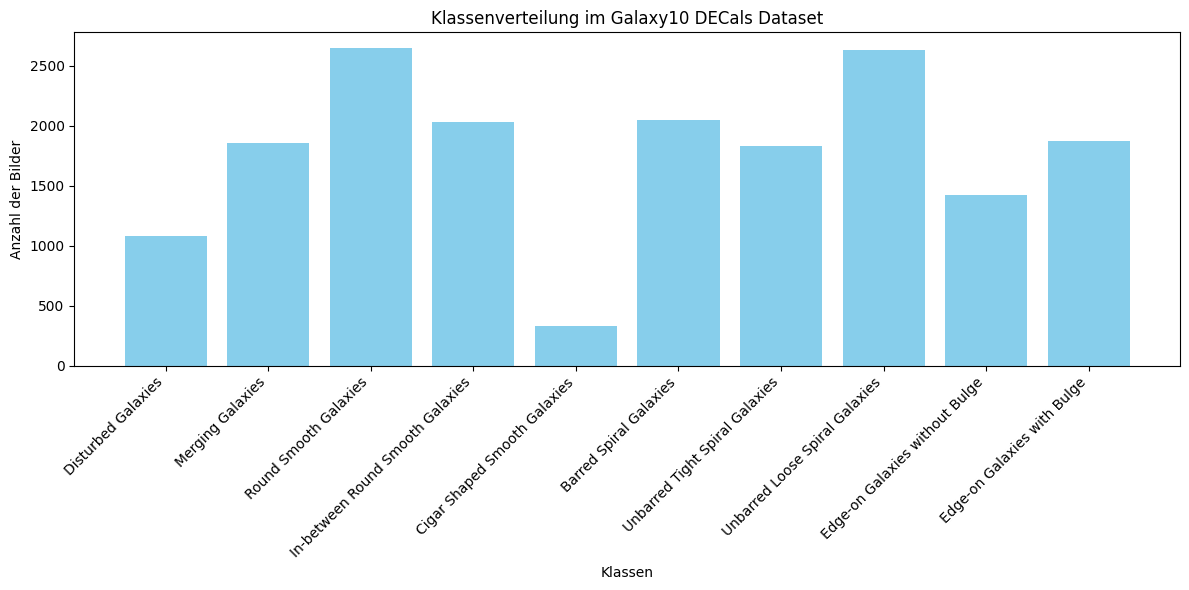

In [13]:
images_raw, labels = load_data(DATA_PATH)
counts = print_class_distribution(labels)
show_class_distribution(counts)

## Splits vorbereiten

`USE_KFOLD` steuert, ob eine k-fache Kreuzvalidierung oder ein einfacher Train/Val-Split durchgeführt wird. Das Test-Set wird in beiden Fällen einmalig und fix abgetrennt.

In [14]:
folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold    = USE_KFOLD,
    k            = K_FOLDS,
    random_state = RANDOM_STATE,
)


Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838


## Fold-Verteilung prüfen

Hier wird visuell geprüft, ob die Stratifizierung funktioniert hat — d.h. ob jeder Fold eine gleichmäßige Klassenverteilung aufweist.

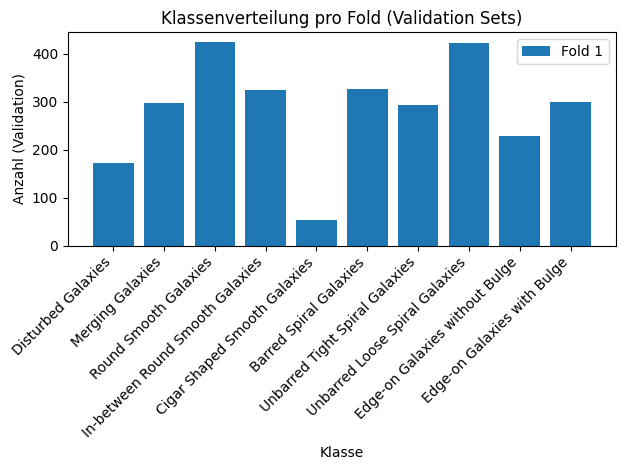

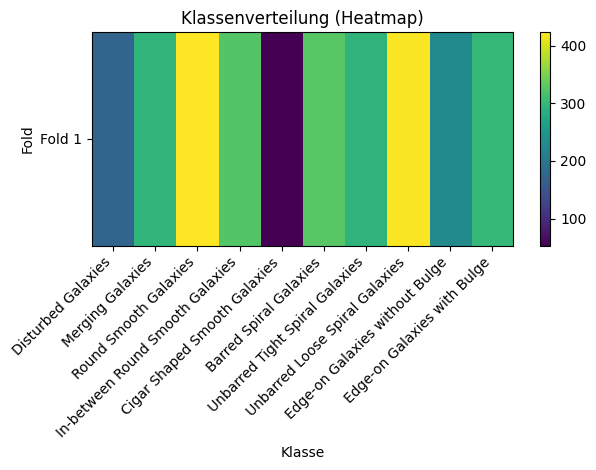

In [15]:
k = len(folds)
fold_class_counts = np.zeros((k, NUM_CLASSES))

for fold_idx, (_, val_idx) in enumerate(folds):
    for cls in range(NUM_CLASSES):
        fold_class_counts[fold_idx, cls] = np.sum(labels[val_idx] == cls)

# Balkendiagramm
x     = np.arange(NUM_CLASSES)
width = 0.8 / k

plt.figure()
for fold_idx in range(k):
    plt.bar(x + fold_idx * width, fold_class_counts[fold_idx], width, label=f"Fold {fold_idx + 1}")

class_names = [LABEL_DICT[i] for i in range(NUM_CLASSES)]
plt.xticks(x + width * (k - 1) / 2, class_names, rotation=45, ha='right')
plt.xlabel("Klasse")
plt.ylabel("Anzahl (Validation)")
plt.title("Klassenverteilung pro Fold (Validation Sets)")
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap
plt.figure()
plt.imshow(fold_class_counts, aspect='auto')
plt.colorbar()
plt.xlabel("Klasse")
plt.ylabel("Fold")
plt.title("Klassenverteilung (Heatmap)")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha='right')
plt.yticks(range(k), [f"Fold {i + 1}" for i in range(k)])
plt.tight_layout()
plt.show()

## Modell

In [18]:
def model_factory():
    """Gibt bei jedem Aufruf ein frisches, kompiliertes Modell zurueck."""

    # Clone erzeugt eine neue Instanz ohne geteilte Gewichte zwischen den Folds
    return build_model(clone_model(MINIMAL_MODEL), learning_rate=LEARNING_RATE)

LOGS_DIR += MINIMAL_MODEL.name

# Einmal aufrufen, um die Architektur zu pruefen — dieses Objekt wird
# NICHT fuer das Training verwendet, nur fuer die Summary!
model_factory().summary(expand_nested=True)

Model: "minimal_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_translation_4            │ (None, 256, 256, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ minimal_cnn (Sequential)        │ (None, 10)             │    33,648,394 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d              │ (None, 128, 128, 32)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_1 (Conv2D)          │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ max_pooling2d_1            │ (None, 64, 64, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_2 (Conv2D)          │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ flatten (Flatten)          │ (None, 524288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 64)             │    33,554,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_1 (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,648,394 (128.36 MB)

 Trainable params: 33,648,394 (128.36 MB)

 Non-trainable params: 0 (0.00 B)

## Training

In [17]:
fold_models, fold_histories = run_training(
    folds         = folds,
    images_raw    = images_raw,
    labels        = labels,
    logs_dir      = LOGS_DIR,
    model_factory = model_factory,
    batch_size    = BATCH_SIZE,
    epochs        = EPOCHS,
    load_models   = LOAD_MODELS,
)


Fold 1 / 1: Starte Training
Epoch 1/100


/home/alexa/Projects/deep-learning/tf-gpu-env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


710/710 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.2181 - loss: 2.0461 - val_accuracy: 0.2340 - val_loss: 2.0178 - learning_rate: 1.0000e-04
Epoch 2/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.2866 - loss: 1.9095 - val_accuracy: 0.3069 - val_loss: 1.8590 - learning_rate: 1.0000e-04
Epoch 3/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.3135 - loss: 1.8644 - val_accuracy: 0.3189 - val_loss: 1.8410 - learning_rate: 1.0000e-04
Epoch 4/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.3416 - loss: 1.8199 - val_accuracy: 0.3633 - val_loss: 1.7957 - learning_rate: 1.0000e-04
Epoch 5/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.3715 - loss: 1.7438 - val_accuracy: 0.3805 - val_loss: 1.7018 - learning_rate: 1.0000e-04
Epoch 6/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.4037 - loss: 1.6536 - val_accuracy: 0.4267 - val_loss: 1.5924 - learning_rate: 1.0000e-04
Epoch 7/100
710/710 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - a

KeyboardInterrupt: 

In [ ]:
# Trainings-Kurven (wird übersprungen wenn LOAD_MODELS=True)
plot_training_history(fold_histories)

## Evaluation

In [ ]:
test_accuracies, best_model, best_fold_idx = evaluate_models(
    fold_models = fold_models,
    images_raw  = images_raw,
    labels      = labels,
    X_test      = X_test,
    batch_size  = BATCH_SIZE,
)

## Ergebnisse

In [ ]:
plot_confusion_matrix(
    best_model    = best_model,
    images_raw    = images_raw,
    labels        = labels,
    X_test        = X_test,
    best_fold_idx = best_fold_idx,
    batch_size    = BATCH_SIZE,
    save_path     = './../reports/milestone-1/confusion_matrix.png',
)